In [8]:
import numpy as np
import pandas as pd

In [9]:
df=pd.read_csv('spamemail_dataset.csv')


In [10]:
df.sample(5)

,Category,Message
934,ham,What time you think you'll have it? Need to kn...
86,ham,For real when u getting on yo? I only need 2 m...
4711,ham,Ya i knw u vl giv..its ok thanks kano..anyway ...
892,ham,I am great princess! What are you thinking abo...
2985,ham,He said that he had a right giggle when he saw...


In [11]:
df.shape

(5572, 2)

# 1). DATA CLEANING

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [13]:

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [14]:
df['Category'] = encoder.fit_transform(df['Category'])

In [15]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
# check null values
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [20]:
#check duplicates
df.duplicated().sum()

np.int64(415)

In [17]:
#drop duplicates
df = df.drop_duplicates(keep='first')

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(5157, 2)

# 2). EDA

In [20]:
 df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
df['Category'].value_counts()

Category
0    4516
1     641
Name: count, dtype: int64

In [22]:
import matplotlib.pyplot as plt

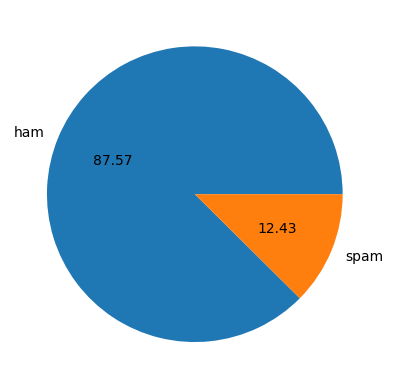

In [23]:
plt.pie(df['Category'].value_counts() , labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

In [31]:
#imbalanced data

In [32]:
!pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 10.0 MB/s eta 0:00:00


In [24]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [25]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [26]:
df['num_characters'] = df['Message'].apply(len)

In [27]:
df.head()

,Category,Message,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [41]:
#no. of words

In [30]:
df['num_words'] = df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [31]:
df.head()

,Category,Message,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
